# tinyCPG Personalization

![fig1_schematic.png](fig1_schematic.png)
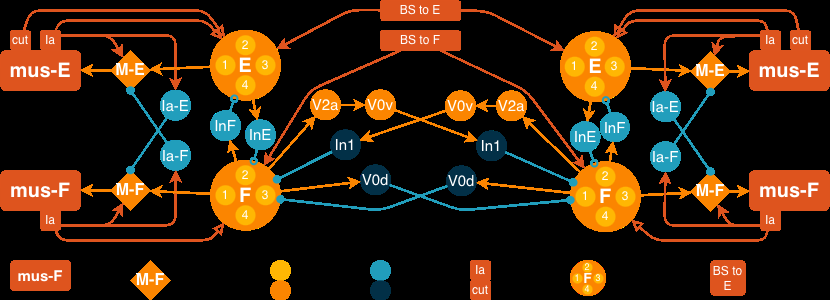

[Reference Model] “max-talanov/tinyCPG: the nest CPG model.” Accessed: Jul. 03, 2026. [Online]. Available: https://github.com/max-talanov/tinyCPG

[Synergy Dataset] S. Fujiki, R. Sakai, T. Funato, and D. Yanagihara, “Dataset of measured kinematics, analysed locomotor parameters, and kinematic synergies of rat hindlimb locomotion during split-belt treadmill walking,” Oct. 2025, doi: 10.5281/zenodo.17310509.

[Locomotion Dataset] [1] S. Fujiki, S. Aoi, T. Funato, Y. Sato, K. Tsuchiya, and D. Yanagihara, “Adaptive hindlimb split-belt treadmill walking in rats by controlling basic muscle activation patterns via phase resetting,” Sci Rep, vol. 8, no. 1, p. 17341, Nov. 2018, doi: 10.1038/s41598-018-35714-8.


In [ ]:
%pip install \
"numpy>=1.24" \
"h5py>=3.8" \
"matplotlib>=3.6" \
"pandas>=3.0.3" \
"nest-simulator>=3.10.0"

## Test Model (TinyTinyCPG, STDP)

In [ ]:
from typing import Any
import nest
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

plt.close('all')

In [ ]:
INIT_IZHI_PARAMS = {
    "a": 0.02,
    "b": 0.2,
    "c": -65.0,
    "d": 8.0,
    "V_th": 30.0,
    "V_min": -120.0,
}

DELAY_MS: float = 1.0
DELAY_COMM_MS: float = 1.0


def clamp(x: float, lo: float, hi: float) -> float:
    return float(max(lo, min(hi, x)))


def poisson_to_parrot(poisson_n: int, parrot_n: int, hz: float) -> Any:
    assert poisson_n == parrot_n, f"one_to_one connection requires equal poisson_n (provided {poisson_n}) and parrot_n (provided {parrot_n})"

    poisson = nest.Create("poisson_generator", poisson_n)
    parrot = nest.Create("parrot_neuron", parrot_n)
    nest.Connect(poisson, parrot, conn_spec={"rule": "one_to_one"})
    nest.SetStatus(poisson, {"rate": hz})
    return poisson, parrot


def create_izhi_population(size: int, params=INIT_IZHI_PARAMS) -> Any:
    return nest.Create("izhikevich", size, params=params)


def create_spike_recorder(target):
    rec = nest.Create("spike_recorder", params={"record_to": "memory"})
    nest.Connect(target, rec)
    return rec

### Leg

In [ ]:
class Leg:  # L/R
    def __init__(self, n_rg_e: int = 100, n_rg_f: int = 100,
                 n_motor_e: int = 100, n_motor_f: int = 100,
                 n_mus_e: int = 100, n_mus_f: int = 100,
                 n_ia_e: int = 100, n_ia_f: int = 100,
                 n_ia_int: int = 50, n_in_e: int = 100,
                 n_in_f: int = 100, n_cut: int = 100,
                 p_rg2m: float = 0.5, p_rg2mus: float = 0.8,
                 p_rg_req: float = 0.12, p_ia2rg: float = 0.4,
                 p_rg_recip: float = 0.20, ia_base_hz: float = 10.0,
                 cut_rate_off_hz: float = 0.0, w_0in: float = 22.0,
                 w0_rm: float = 30.0, w_m2mus: float = 1.0,
                 w_rg: float = 8.0, w_rg_recip: float = -18.0,
                 ia2rg_w: float = 12.0):

        self.rg_e = create_izhi_population(n_rg_e)
        self.rg_f = create_izhi_population(n_rg_f)
        self.m_e = create_izhi_population(n_motor_e)
        self.m_f = create_izhi_population(n_motor_f)
        self.ia_int = create_izhi_population(n_ia_int)
        self.ia_e, self.in_e = poisson_to_parrot(n_ia_e, n_in_e, ia_base_hz)
        self.ia_f, self.in_f = poisson_to_parrot(n_ia_f, n_in_f, ia_base_hz)
        self.cut_pg, self.cut_in = poisson_to_parrot(n_cut, n_cut, cut_rate_off_hz)
        self.mus_e = nest.Create("parrot_neuron", n_mus_e)
        self.mus_f = nest.Create("parrot_neuron", n_mus_f)

        self.rec_muse = nest.Create("spike_recorder", params={"record_to": "memory"})
        self.rec_musf = nest.Create("spike_recorder", params={"record_to": "memory"})

        nest.Connect(self.cut_in, self.rg_e,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_rg2m},
                     syn_spec={"synapse_model": "static_synapse", "weight": w_0in, "delay": DELAY_MS})  # CUT -> RG_E

        nest.Connect(self.rg_f, self.m_f,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_rg2m},
                     syn_spec={"synapse_model": "static_synapse", "weight": w0_rm,
                               "delay": DELAY_MS})  # RG_E -> MOTOR_E
        nest.Connect(self.rg_e, self.m_e,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_rg2m},
                     syn_spec={"synapse_model": "static_synapse", "weight": w0_rm,
                               "delay": DELAY_MS})  # RG_F -> MOTOR_F

        nest.Connect(self.m_e, self.mus_e,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_rg2mus},
                     syn_spec={"synapse_model": "static_synapse", "weight": w_m2mus,
                               "delay": DELAY_MS})  # M_E -> EXTENSOR
        nest.Connect(self.m_f, self.mus_f,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_rg2mus},
                     syn_spec={"synapse_model": "static_synapse", "weight": w_m2mus,
                               "delay": DELAY_MS})  # M_F -> FLEXOR

        nest.Connect(self.rg_e, self.rg_e,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_rg_req},
                     syn_spec={"synapse_model": "static_synapse", "weight": w_rg,
                               "delay": DELAY_MS})  # RG_E -> RG_E (recursive)
        nest.Connect(self.rg_f, self.rg_f,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_rg_req},
                     syn_spec={"synapse_model": "static_synapse", "weight": w_rg,
                               "delay": DELAY_MS})  # RG_E -> RG_E (recursive)

        nest.Connect(self.rg_e, self.rg_f,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_rg_recip},
                     syn_spec={"synapse_model": "static_synapse", "weight": w_rg_recip,
                               "delay": DELAY_MS})  # RG_E -> RG_F
        nest.Connect(self.rg_f, self.rg_e,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_rg_recip},
                     syn_spec={"synapse_model": "static_synapse", "weight": w_rg_recip,
                               "delay": DELAY_MS})  # RG_F -> RG_E

        nest.Connect(self.ia_e, self.rg_e,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_ia2rg},
                     syn_spec={"synapse_model": "static_synapse", "weight": ia2rg_w,
                               "delay": DELAY_MS})  # IA_E (spindle sensor extensor) -> RG_E
        nest.Connect(self.ia_f, self.rg_f,
                     conn_spec={"rule": "pairwise_bernoulli", "p": p_ia2rg},
                     syn_spec={"synapse_model": "static_synapse", "weight": ia2rg_w,
                               "delay": DELAY_MS})  # IA_F (spindle sensor extensor) -> RG_F

        self.rec_muse = create_spike_recorder(self.mus_e)
        self.rec_musf = create_spike_recorder(self.mus_f)

    def mus_is_spiked(self, current_time):
        e_spiked = False
        if len(self.rec_muse.times) > 0 and self.rec_muse.times[-1] == current_time:
            e_spiked = True

        f_spiked = False
        if len(self.rec_musf.times) > 0 and self.rec_musf.times[-1] == current_time:
            f_spiked = True

        return e_spiked, f_spiked


### Brain Stem

In [ ]:
class BrainStem:
    def __init__(self, n_bs: int = 100, bs_rate_base_hz: float = 0.0,
                 bs_rate_amp_hz: float = 300.0, bs_noise_std_hz: float = 0.0,
                 bs_osc_hz: float = 1.0, base_drive_hz: float = 10.0,
                 bs_phase={"L": 0.0, "R": np.pi}):
        self.bs_pg_e, self.bs_in_e = poisson_to_parrot(n_bs, n_bs, bs_rate_base_hz)
        self.bs_pg_f, self.bs_in_f = poisson_to_parrot(n_bs, n_bs, bs_rate_base_hz)
        self.base_pg, self.base_in = poisson_to_parrot(n_bs, n_bs, base_drive_hz)

        self.bs_osc_hz = bs_osc_hz
        self.bs_rate_amp_hz = bs_rate_amp_hz
        self.bs_rate_base_hz = bs_rate_base_hz
        self.bs_noise_std_hz = bs_noise_std_hz
        self.bs_phase = bs_phase

    def bs_rates_counterphase(self, t_ms: float = 1, corr: float = 0.5, leg: str = "L") -> tuple[float, float]:
        t_s = t_ms / 1000.0
        s = np.sin(2.0 * np.pi * self.bs_osc_hz * t_s + self.bs_phase[leg])
        e = max(0.0, s)
        f = max(0.0, -s)

        common_noise = np.random.normal(0.0, self.bs_noise_std_hz * corr)
        indep_noise_e = np.random.normal(0.0, self.bs_noise_std_hz * (1 - corr))
        indep_noise_f = np.random.normal(0.0, self.bs_noise_std_hz * (1 - corr))

        noise_e = common_noise + indep_noise_e
        noise_f = common_noise + indep_noise_f

        r_e = self.bs_rate_base_hz + self.bs_rate_amp_hz * e + noise_e
        r_f = self.bs_rate_base_hz + self.bs_rate_amp_hz * f + noise_f

        r_e = clamp(r_e, self.bs_rate_base_hz,
                    self.bs_rate_base_hz + self.bs_rate_amp_hz + self.bs_noise_std_hz * 3)  # 3σ rule - 99.7% coverage
        r_f = clamp(r_f, self.bs_rate_base_hz,
                    self.bs_rate_base_hz + self.bs_rate_amp_hz + self.bs_noise_std_hz * 3)  # 3σ rule - 99.7% coverage
        return r_e, r_f

### Main Model

#### HipJointRec (Tracking Data)

In [ ]:

# "TAU_ACT_RISE_MS
# "TAU_ACT_DECAY_MS
# "ACT_SAT_K"
# "ACT_GATE_POWER"
# "ACT_MAX"
# "TAU_FORCE_RISE_MS"
# "TAU_FORCE_DECAY_MS"
# "FORCE_MAX"
# "FORCE_SAT_K"
# "TAU_LENGTH_MS"
# "L0"
# "SHORTEN_GAIN"
# "STRETCH_GAIN"

class HipJointRec:
    def __init__(self, dt: float = 0.01, tau_m=0.02,
                 act_f: float = 0.0, act_e: float = 0.0, current_angle: float = 0.0,
                 velocity: float = 0.0, inertia: float = 0.05,
                 dampling: float = 0.1, gain: float = 1.0):
        self.dt = dt
        self.act_e = act_e
        self.act_f = act_f
        self.tau_m = tau_m  # Muscle time constant (20ms)

        self.angle = current_angle  # Current hip angle (degrees)
        self.velocity = velocity  # Angular velocity
        self.I = inertia  # Moment of inertia
        self.b = dampling  # Damping coefficient
        self.gain = gain  # Scaling factor from spikes to torque

        # Stance/Swing
        self.current_stance_time = 0.0
        self.current_swing_time = 0.0
        self.t_stance = 0.0
        self.t_swing = 0.0
        self.was_stance = False

        #Synergy
        self.syn1_spikes = 0
        self.syn2_spikes = 0

    def step(self, e_spiked, f_spiked):
        self.act_e += (-self.act_e / 0.02 + (1.0 if e_spiked else 0.0)) * self.dt
        self.act_f += (-self.act_f / 0.02 + (1.0 if f_spiked else 0.0)) * self.dt

        torque = 1.0 * (self.act_e - self.act_f)
        accel = (torque - 0.1 * self.velocity) / 0.05
        self.velocity += accel * self.dt
        self.angle += self.velocity * self.dt

        if e_spiked: self.syn1_spikes += 1
        if f_spiked: self.syn2_spikes += 1

    def update_hip_angle(self, rec_muse_spiked, rec_musf_spiked):
        e_spiked = 0.0
        if rec_muse_spiked:
            e_spiked = 1.0

        f_spiked = 0.0
        if rec_musf_spiked:
            f_spiked = 1.0

        self.act_e += (-self.act_e / self.tau_m + e_spiked) * self.dt
        self.act_f += (-self.act_f / self.tau_m + f_spiked) * self.dt
        torque = self.gain * (self.act_e - self.act_f)

        acceleration = (torque - self.b * self.velocity) / self.I

        self.velocity += acceleration * self.dt
        self.angle += self.velocity * self.dt

        return self.angle

    def get_duty_factor(self) -> float:
        is_stance = self.act_e > self.act_f
        is_touchdown = is_stance and not self.was_stance

        if is_touchdown:
            self.t_stance = self.current_stance_time
            self.t_swing = self.current_swing_time

            t_total = self.t_stance + self.t_swing

            if t_total > 0.0:
                return self.t_stance / t_total

            self.current_stance_time = 0.0
            self.current_swing_time = 0.0

        if is_stance:
            self.current_stance_time += self.dt
        else:
            self.current_swing_time += self.dt
        self.was_stance = is_stance

        return 0.0




In [ ]:
class L2CPG:
    def __init__(self, bs: BrainStem, legs: dict[str, Leg], p_con: float = 0.5,
                 p_comm: float = 0.08, base_drive_p: float = 0.08, base_drive_w: float = 18.0,
                 w_comm_inh: float = -10.0, enable_commissural: bool = True):

        for leg_key, leg in legs.items():
            nest.Connect(bs.bs_in_e, leg.rg_e,
                         conn_spec={"rule": "pairwise_bernoulli", "p": p_con},
                         syn_spec={"synapse_model": "static_synapse", "weight": base_drive_w, "delay": DELAY_MS})
            nest.Connect(bs.bs_in_f, leg.rg_f,
                         conn_spec={"rule": "pairwise_bernoulli", "p": p_con},
                         syn_spec={"synapse_model": "static_synapse", "weight": base_drive_w, "delay": DELAY_MS})

            nest.Connect(bs.base_in, leg.rg_e,
                         conn_spec={"rule": "pairwise_bernoulli", "p": base_drive_p},
                         syn_spec={"synapse_model": "static_synapse", "weight": base_drive_w, "delay": DELAY_MS})
            nest.Connect(bs.base_in, leg.rg_f,
                         conn_spec={"rule": "pairwise_bernoulli", "p": base_drive_p},
                         syn_spec={"synapse_model": "static_synapse", "weight": base_drive_w, "delay": DELAY_MS})

        if enable_commissural:
            LL = legs["L"]
            RR = legs["R"]

            nest.Connect(LL.rg_e, RR.rg_f, conn_spec={"rule": "pairwise_bernoulli", "p": p_comm},
                         syn_spec={"synapse_model": "static_synapse", "weight": w_comm_inh, "delay": DELAY_COMM_MS})
            nest.Connect(RR.rg_e, LL.rg_f, conn_spec={"rule": "pairwise_bernoulli", "p": p_comm},
                         syn_spec={"synapse_model": "static_synapse", "weight": w_comm_inh, "delay": DELAY_COMM_MS})
            nest.Connect(LL.rg_f, RR.rg_e, conn_spec={"rule": "pairwise_bernoulli", "p": p_comm},
                         syn_spec={"synapse_model": "static_synapse", "weight": w_comm_inh, "delay": DELAY_COMM_MS})
            nest.Connect(RR.rg_f, LL.rg_e, conn_spec={"rule": "pairwise_bernoulli", "p": p_comm},
                         syn_spec={"synapse_model": "static_synapse", "weight": w_comm_inh, "delay": DELAY_COMM_MS})

        self.legs = legs
        self.bs = bs
        self.joint_rec = HipJointRec  # default for now

    def get_output(self, current_frame) -> dict[str, float]:
        output = {
            "LH_duty_factor": 0.0, "RH_duty_factor": 0.0, "LH_double_support": 0.0,
            "RH_double_support": 0.0, "LH_step_length": 0.0, "RH_step_length": 0.0,
            "LH_stride_length": 0.0, "RH_stride_length": 0.0, "LH_Synergy_1_contribution": 0.0,
            "LH_Synergy_2_contribution": 0.0, "RH_Synergy_1_contribution": 0.0, "RH_Synergy_2_contribution": 0.0
        }

        for leg_key, leg in legs.items():
            duty_factor = self.joint_rec.get_duty_factor(leg)
            output["LH_duty_factor"] = duty_factor
        return




In [ ]:
nest.ResetKernel()
nest.local_num_threads = 4
print("Model initialization")

bs = BrainStem(bs_rate_amp_hz=250.0, bs_osc_hz=1.5, base_drive_hz=15.0)

legs = {
    "L": Leg(cut_rate_off_hz=0.0),
    "R": Leg(cut_rate_off_hz=0.0)
}

cpg = L2CPG(bs, legs, p_comm=0.1, w_comm_inh=-12.0)

dt = 10.0
sim_time = 150.0
steps = int(sim_time / dt)

print(f"Starting simulation {sim_time} ms steps {dt} ms")

rate_history_E_L = []
rate_history_F_L = []

for step in range(steps):
    t_ms = step * dt

    r_e_l, r_f_l = bs.bs_rates_counterphase(t_ms, leg="L")
    r_e_r, r_f_r = bs.bs_rates_counterphase(t_ms, leg="R")

    rate_history_E_L.append(r_e_l)
    rate_history_F_L.append(r_f_l)

    nest.SetStatus(bs.bs_pg_e, {"rate": r_e_l})
    nest.SetStatus(bs.bs_pg_f, {"rate": r_f_l})

    nest.Simulate(dt)

print("Simulation finished")


def get_raster_data(recorder):
    events = recorder.get("events")
    return events["times"], events["senders"]


t_e_l, id_e_l = get_raster_data(legs["L"].rec_muse)
t_f_l, id_f_l = get_raster_data(legs["L"].rec_musf)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

time_axis = np.arange(0, sim_time, dt)
ax1.plot(time_axis, rate_history_E_L, label="BrainStem -> Extensor (L)", color="royalblue")
ax1.plot(time_axis, rate_history_F_L, label="BrainStem -> Flexor (L)", color="crimson")
ax1.set_ylabel("Generator Freq (hZ)")
ax1.set_title("Brain Stem input modulation signal")
ax1.legend()
ax1.grid(True)

if len(t_e_l) > 0:
    ax2.scatter(t_e_l, id_e_l, color="blue", s=10, marker="|", label="Extensor Muscles (L)")
else:
    print("Warning: No spikes (Extensor Muscles)")

if len(t_f_l) > 0:
    ax2.scatter(t_f_l, id_f_l, color="red", s=10, marker="|", label="Flexor Muscles (L)")
else:
    print("Warning: No spikes (Flexor Muscles)")

ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("ID Target Neurons")
ax2.set_title("Motor pool activity")
ax2.legend()
ax2.grid(True)

plt.tight_layout()

fig

In [ ]:
predictions = []

for i in range(0, 100):
    rng = np.random.default_rng()

## Persona (PPO, Pytorch)

In [ ]:
import torch.nn as nn
import torch.optim as optim


class PersonaModel(nn.Module):
    def __init__(self, num_params: int, num_metrics):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(num_metrics, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
        )
        self.mu = nn.Linear(64, num_params)
        self.log_std = nn.Linear(64, num_params)



## Environment (EMG)

In [ ]:
import csv

EMG_DATA_FOLDER_PATH = "data/emg/"
TRACKING_FOLDER_PATH = "data/other/"

In [ ]:
import csv
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset


class Environment:
    def __init__(self, model_cpg: L2CPG, model_persona: PersonaModel, dataset_path: str, init_step: int, dt: float):
        self.model_cpg = model_cpg
        self.persona = model_persona

        self.current_frame = init_step
        self.dt = dt

        self.data = pd.read_csv(dataset_path).values

        x = torch.tensor(self.data[:, 0], dtype=torch.float32).reshape(-1, 1)
        y = torch.tensor(self.data[:, 1], dtype=torch.float32).reshape(-1, 1)

        dataset = TensorDataset(x, y)
        self.dataloader = iter(DataLoader(dataset, batch_size=1, shuffle=False))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

    def step(self):
        time, target = next(self.dataloader)


        self.current_frame += 1





In [ ]:
import csv
import pandas as pd

DATASET_FOLDER_PATH = "D:/TinyTinyCPG/data/emg/DatasetStatisticalAnalysis"


class Environment:
    def __init__(self, model_cpg: L2CPG, model_persona: PersonaModel, init_step: int, file_name: str,
                 target_flexor_name: str, target_extensor_name: str,
                 target_angle_name: str):
        self.model_cpg = model_cpg
        self.model_persona = model_persona

        self.current_frame: int = init_step
        self.target_flexor = target_flexor_name
        self.target_extensor = target_extensor_name
        self.target_angle = target_angle_name
        self.df = pd.read_csv(DATASET_FOLDER_PATH + file_name)

    def step(self):
        targets = self.df.to_dict(orient='records')
        cpg_output = self.model_cpg.get_output(current_frame=self.current_frame)

        self.current_frame += 1
        return targets[self.current_step]

    def reward(self, output):

# Preprocessing


## Test Model (TinyTinyCPG, STDP)

In [ ]:
INIT_IZHI_PARAMS = {
    "a": 0.02,
    "b": 0.2,
    "c": -65.0,
    "d": 8.0,
    "V_th": 30.0,
    "V_min": -120.0,
}

TAU_PLUS = 20.0
# Lower learning rate and mild LTP/LTD balance + multiplicative STDP to reduce hard-boundary pileups at 0/Wmax
LAMBDA = 0.001
ALPHA = 0.95
MU_PLUS = 0.4
MU_MINUS = 0.4
WMAX = 120.0

stdp_defaults = {
    "tau_plus": TAU_PLUS,
    "lambda": LAMBDA,
    "alpha": ALPHA,
    "mu_plus": MU_PLUS,
    "mu_minus": MU_MINUS,
    "Wmax": WMAX,
}

In [ ]:
RES = 0.1

nest.ResetKernel()
nest.SetKernelStatus({"resolution": RES})

## Experiment 1 (2legs, noSTDP, noPersona)

In [ ]:
INIT_IZHI_PARAMS = {
    "a": 0.02,
    "b": 0.2,
    "c": -65.0,
    "d": 8.0,
    "V_th": 30.0,
    "V_min": -120.0,
}

TAU_PLUS = 20.0
# Lower learning rate and mild LTP/LTD balance + multiplicative STDP to reduce hard-boundary pileups at 0/Wmax
LAMBDA = 0.001
ALPHA = 0.95
MU_PLUS = 0.4
MU_MINUS = 0.4
WMAX = 120.0

stdp_defaults = {
    "tau_plus": TAU_PLUS,
    "lambda": LAMBDA,
    "alpha": ALPHA,
    "mu_plus": MU_PLUS,
    "mu_minus": MU_MINUS,
    "Wmax": WMAX,
}